In [53]:
sample_news = [
    "Apple launched a new smartphone with advanced artificial intelligence features."
]

prediction = loaded_model.predict(sample_news)

print("Predicted Category:", prediction[0])

Predicted Category: tech


In [52]:
loaded_model = joblib.load("../news_classification_model.pkl")

print(loaded_model)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(ngram_range=(1, 2), stop_words='english')),
                ('model', LinearSVC(C=0.5, random_state=42))])


In [51]:
import joblib

joblib.dump(
    final_model,
    "../news_classification_model.pkl"
)

['../news_classification_model.pkl']

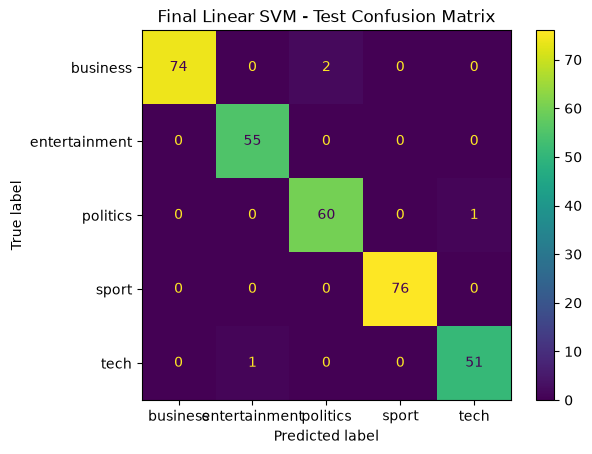

In [50]:
cm_test = confusion_matrix(
    y_test,
    test_pred,
    labels=final_model.named_steps["model"].classes_
)

disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=final_model.named_steps["model"].classes_
)

disp_test.plot()
plt.title("Final Linear SVM - Test Confusion Matrix")
plt.show()

In [49]:
from sklearn.metrics import accuracy_score, f1_score

test_accuracy = accuracy_score(y_test, test_pred)
test_macro_f1 = f1_score(y_test, test_pred, average="macro")

print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Macro F1: {test_macro_f1:.4f}")

Final Test Accuracy: 0.9875
Final Test Macro F1: 0.9868


In [48]:
test_pred = final_model.predict(X_test)

print(classification_report(y_test, test_pred))

               precision    recall  f1-score   support

     business       1.00      0.97      0.99        76
entertainment       0.98      1.00      0.99        55
     politics       0.97      0.98      0.98        61
        sport       1.00      1.00      1.00        76
         tech       0.98      0.98      0.98        52

     accuracy                           0.99       320
    macro avg       0.99      0.99      0.99       320
 weighted avg       0.99      0.99      0.99       320



In [47]:
final_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        min_df=1,
        ngram_range=(1, 2)
    )),
    ("model", LinearSVC(
        C=0.5,
        random_state=42
    ))
])

final_model.fit(X_train_final, y_train_final)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](5,)","['business','entertainment','politics','sport','tech']"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDe

In [46]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

print("Final training samples:", X_train_final.shape[0])
print("Final test samples:", X_test.shape[0])

Final training samples: 1807
Final test samples: 320


In [45]:
import numpy as np

for class_index, class_name in enumerate(svm.classes_):

    top_indices = np.argsort(
        svm.coef_[class_index]
    )[-10:][::-1]

    top_features = feature_names[top_indices]

    print(f"\nTop features for {class_name}:")
    print(top_features)


Top features for business:
['bank' 'shares' 'market' 'firm' 'economy' 'company' 'oil' 'growth'
 'economic' 'sales']

Top features for entertainment:
['film' 'band' 'music' 'album' 'singer' 'star' 'festival' 'films' 'award'
 'tv']

Top features for politics:
['mr' 'labour' 'party' 'blair' 'election' 'government' 'minister'
 'secretary' 'police' 'said']

Top features for sport:
['match' 'win' 'injury' 'cup' 'coach' 'season' 'club' 'players' 'rugby'
 'team']

Top features for tech:
['technology' 'computer' 'software' 'users' 'digital' 'mobile' 'online'
 'games' 'people' 'game']


In [44]:
vectorizer = best_svm_model.named_steps["tfidf"]
svm = best_svm_model.named_steps["model"]

feature_names = vectorizer.get_feature_names_out()

print("Number of TF-IDF features:", len(feature_names))

Number of TF-IDF features: 260238


In [43]:
for idx, row in errors.iterrows():
    print("=" * 80)
    print("Actual:", row["actual"])
    print("Predicted:", row["predicted"])
    print("Text snippet:")
    print(row["text"][:500])
    print()

Actual: sport
Predicted: business
Text snippet:
Ferdinand casts doubt over Glazer

Rio Ferdinand has said he is unsure of Malcolm Glazer's motives after the American billionaire launched a new offer to buy Manchester United.

The club have confirmed that the Glazer Family Partnership have submitted proposals of a third bid. "A lot of people want the club's interest to be with people who have grown up with the club and have got its interests at heart," said Ferdinand. "No one knows what this guy will be bringing to the table." The central defe

Actual: politics
Predicted: entertainment
Text snippet:
UK helps raped Rwandan women

Britain is to give a £4m grant to help women survivors of the Rwandan genocide who were raped and often deliberately infected with HIV/Aids.

An estimated 25,000 girls and women were raped during the 1994 genocide. About 800,000 Tutsis and moderate Hutus were killed by Hutu militias after the assassination of an ethnic Hutu leader. The five-year Department for I

In [42]:
error_df = pd.DataFrame({
    "text": X_val,
    "actual": y_val,
    "predicted": best_val_pred
})

errors = error_df[
    error_df["actual"] != error_df["predicted"]
]

print("Total misclassified articles:", len(errors))

errors[["actual", "predicted"]]

Total misclassified articles: 8


,actual,predicted
1396,sport,business
1011,politics,entertainment
717,entertainment,tech
252,business,politics
241,business,tech
1049,politics,business
909,politics,sport
20,business,entertainment


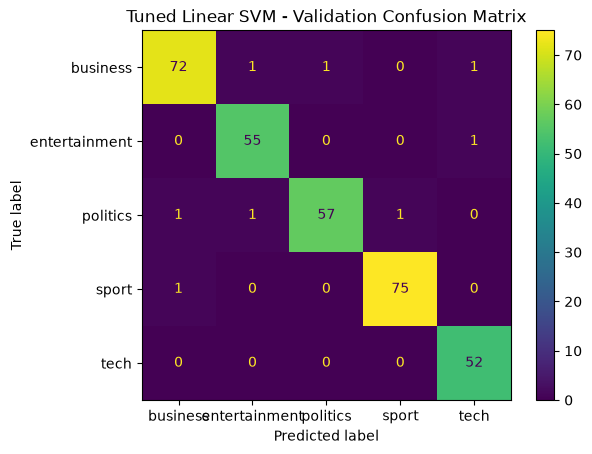

In [41]:
cm_best = confusion_matrix(
    y_val,
    best_val_pred,
    labels=best_svm_model.named_steps["model"].classes_
)

disp_best = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=best_svm_model.named_steps["model"].classes_
)

disp_best.plot()
plt.title("Tuned Linear SVM - Validation Confusion Matrix")
plt.show()

In [40]:
best_val_pred = best_svm_model.predict(X_val)

print(classification_report(y_val, best_val_pred))

               precision    recall  f1-score   support

     business       0.97      0.96      0.97        75
entertainment       0.96      0.98      0.97        56
     politics       0.98      0.95      0.97        60
        sport       0.99      0.99      0.99        76
         tech       0.96      1.00      0.98        52

     accuracy                           0.97       319
    macro avg       0.97      0.98      0.97       319
 weighted avg       0.98      0.97      0.97       319



In [39]:
best_svm_model = grid_search.best_estimator_

best_train_accuracy = best_svm_model.score(X_train, y_train)
best_val_accuracy = best_svm_model.score(X_val, y_val)

print(f"Training Accuracy: {best_train_accuracy:.4f}")
print(f"Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Gap: {best_train_accuracy - best_val_accuracy:.4f}")

Training Accuracy: 1.0000
Validation Accuracy: 0.9749
Gap: 0.0251


In [38]:
from sklearn.model_selection import GridSearchCV

svm_tuning_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english"
    )),
    ("model", LinearSVC(
        random_state=42
    ))
])

param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 3],
    "model__C": [0.1, 0.5, 1.0]
}

grid_search = GridSearchCV(
    svm_tuning_pipeline,
    param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Macro F1:", grid_search.best_score_)

Best Parameters: {'model__C': 0.5, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}
Best CV Macro F1: 0.9767474326201416


In [37]:
logistic_f1_scores = cross_val_score(
    logistic_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_macro"
)

nb_f1_scores = cross_val_score(
    nb_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_macro"
)

svm_f1_scores = cross_val_score(
    svm_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_macro"
)

print("Logistic Regression Macro F1:", logistic_f1_scores.mean())
print("Naive Bayes Macro F1:", nb_f1_scores.mean())
print("Linear SVM Macro F1:", svm_f1_scores.mean())

Logistic Regression Macro F1: 0.9721738142337932
Naive Bayes Macro F1: 0.9734289266198175
Linear SVM Macro F1: 0.9749455224210178


In [36]:
svm_cv_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        min_df=2
    )),
    ("model", LinearSVC(
        C=0.5,
        random_state=42
    ))
])

svm_cv_scores = cross_val_score(
    svm_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("CV Scores:", svm_cv_scores)
print("Mean CV Accuracy:", svm_cv_scores.mean())
print("CV Std:", svm_cv_scores.std())

CV Scores: [0.97986577 0.95973154 0.97651007 0.97979798 0.97979798]
Mean CV Accuracy: 0.975140668429259
CV Std: 0.007810557987313031


In [35]:
nb_cv_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        min_df=2
    )),
    ("model", MultinomialNB(
        alpha=0.1
    ))
])

nb_cv_scores = cross_val_score(
    nb_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("CV Scores:", nb_cv_scores)
print("Mean CV Accuracy:", nb_cv_scores.mean())
print("CV Std:", nb_cv_scores.std())

CV Scores: [0.97986577 0.95973154 0.97986577 0.97979798 0.97306397]
Mean CV Accuracy: 0.974465008022055
CV Std: 0.00782067719717276


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

logistic_cv_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        min_df=2
    )),
    ("model", LogisticRegression(
        C=2,
        max_iter=1000,
        random_state=42
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_cv_scores = cross_val_score(
    logistic_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("CV Scores:", logistic_cv_scores)
print("Mean CV Accuracy:", logistic_cv_scores.mean())
print("CV Std:", logistic_cv_scores.std())

CV Scores: [0.96979866 0.96308725 0.96644295 0.98653199 0.97643098]
Mean CV Accuracy: 0.9724583644046731
CV Std: 0.00830572713866561


In [33]:
c_values = [0.01, 0.1, 0.5, 1, 2, 10]

for c in c_values:
    model = LinearSVC(
        C=c,
        random_state=42
    )

    model.fit(X_train_tfidf, y_train)

    train_acc = model.score(X_train_tfidf, y_train)
    val_acc = model.score(X_val_tfidf, y_val)

    print(
        f"C={c:<5} | "
        f"Train={train_acc:.4f} | "
        f"Validation={val_acc:.4f} | "
        f"Gap={train_acc - val_acc:.4f}"
    )

C=0.01  | Train=0.9368 | Validation=0.9122 | Gap=0.0246
C=0.1   | Train=0.9966 | Validation=0.9718 | Gap=0.0249
C=0.5   | Train=1.0000 | Validation=0.9749 | Gap=0.0251
C=1     | Train=1.0000 | Validation=0.9749 | Gap=0.0251
C=2     | Train=1.0000 | Validation=0.9749 | Gap=0.0251
C=10    | Train=1.0000 | Validation=0.9749 | Gap=0.0251


In [32]:
alpha_values = [0.01, 0.1, 0.5, 1, 2, 5, 10]

for alpha in alpha_values:
    model = MultinomialNB(alpha=alpha)

    model.fit(X_train_tfidf, y_train)

    train_acc = model.score(X_train_tfidf, y_train)
    val_acc = model.score(X_val_tfidf, y_val)

    print(
        f"alpha={alpha:<5} | "
        f"Train={train_acc:.4f} | "
        f"Validation={val_acc:.4f} | "
        f"Gap={train_acc - val_acc:.4f}"
    )

alpha=0.01  | Train=1.0000 | Validation=0.9718 | Gap=0.0282
alpha=0.1   | Train=0.9960 | Validation=0.9749 | Gap=0.0210
alpha=0.5   | Train=0.9919 | Validation=0.9718 | Gap=0.0201
alpha=1     | Train=0.9866 | Validation=0.9718 | Gap=0.0148
alpha=2     | Train=0.9819 | Validation=0.9655 | Gap=0.0163
alpha=5     | Train=0.9530 | Validation=0.9216 | Gap=0.0313
alpha=10    | Train=0.8898 | Validation=0.8433 | Gap=0.0465


In [31]:
c_values = [0.01, 0.1, 0.5, 1, 2, 10]

for c in c_values:
    model = LogisticRegression(
        C=c,
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train_tfidf, y_train)

    train_acc = model.score(X_train_tfidf, y_train)
    val_acc = model.score(X_val_tfidf, y_val)

    print(
        f"C={c:<5} | "
        f"Train={train_acc:.4f} | "
        f"Validation={val_acc:.4f} | "
        f"Gap={train_acc - val_acc:.4f}"
    )

C=0.01  | Train=0.4852 | Validation=0.4734 | Gap=0.0119
C=0.1   | Train=0.9328 | Validation=0.9060 | Gap=0.0268
C=0.5   | Train=0.9946 | Validation=0.9718 | Gap=0.0228
C=1     | Train=0.9966 | Validation=0.9749 | Gap=0.0217
C=2     | Train=1.0000 | Validation=0.9781 | Gap=0.0219
C=10    | Train=1.0000 | Validation=0.9749 | Gap=0.0251


In [30]:
from sklearn.metrics import f1_score
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Linear SVM"
    ],
    "Train Accuracy": [
        train_accuracy,
        nb_train_accuracy,
        svm_train_accuracy
    ],
    "Validation Accuracy": [
        val_accuracy,
        nb_val_accuracy,
        svm_val_accuracy
    ],
    "Train-Val Gap": [
        train_accuracy - val_accuracy,
        nb_train_accuracy - nb_val_accuracy,
        svm_train_accuracy - svm_val_accuracy
    ],
    "Macro F1": [
        f1_score(y_val, y_val_pred, average="macro"),
        f1_score(y_val, nb_val_pred, average="macro"),
        f1_score(y_val, svm_val_pred, average="macro")
    ]
})

comparison

,Model,Train Accuracy,Validation Accuracy,Train-Val Gap,Macro F1
0,Logistic Regression,0.996640,0.974922,0.021718,0.974844
1,Multinomial Naive Bayes,0.986559,0.971787,0.014772,0.970848
2,Linear SVM,1.000000,0.974922,0.025078,0.974231


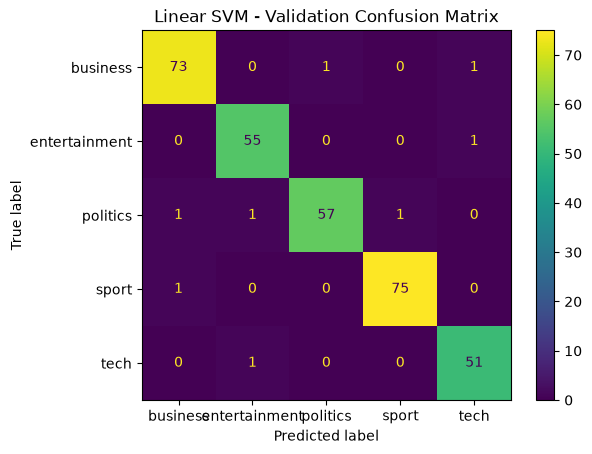

In [29]:
cm_svm = confusion_matrix(
    y_val,
    svm_val_pred,
    labels=svm_model.classes_
)

disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=svm_model.classes_
)

disp_svm.plot()
plt.title("Linear SVM - Validation Confusion Matrix")
plt.show()

In [28]:
svm_val_pred = svm_model.predict(X_val_tfidf)

print(classification_report(y_val, svm_val_pred))

               precision    recall  f1-score   support

     business       0.97      0.97      0.97        75
entertainment       0.96      0.98      0.97        56
     politics       0.98      0.95      0.97        60
        sport       0.99      0.99      0.99        76
         tech       0.96      0.98      0.97        52

     accuracy                           0.97       319
    macro avg       0.97      0.97      0.97       319
 weighted avg       0.98      0.97      0.97       319



In [27]:
svm_train_accuracy = svm_model.score(X_train_tfidf, y_train)
svm_val_accuracy = svm_model.score(X_val_tfidf, y_val)

print(f"Training Accuracy: {svm_train_accuracy:.4f}")
print(f"Validation Accuracy: {svm_val_accuracy:.4f}")
print(f"Gap: {svm_train_accuracy - svm_val_accuracy:.4f}")

Training Accuracy: 1.0000
Validation Accuracy: 0.9749
Gap: 0.0251


In [26]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adj

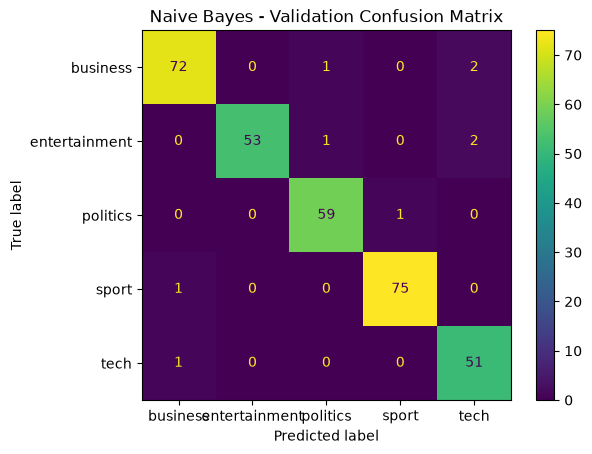

In [25]:
cm_nb = confusion_matrix(
    y_val,
    nb_val_pred,
    labels=nb_model.classes_
)

disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=nb_model.classes_
)

disp_nb.plot()
plt.title("Naive Bayes - Validation Confusion Matrix")
plt.show()

In [24]:
nb_val_pred = nb_model.predict(X_val_tfidf)

print(classification_report(y_val, nb_val_pred))

               precision    recall  f1-score   support

     business       0.97      0.96      0.97        75
entertainment       1.00      0.95      0.97        56
     politics       0.97      0.98      0.98        60
        sport       0.99      0.99      0.99        76
         tech       0.93      0.98      0.95        52

     accuracy                           0.97       319
    macro avg       0.97      0.97      0.97       319
 weighted avg       0.97      0.97      0.97       319



In [23]:
nb_train_accuracy = nb_model.score(X_train_tfidf, y_train)
nb_val_accuracy = nb_model.score(X_val_tfidf, y_val)

print(f"Training Accuracy: {nb_train_accuracy:.4f}")
print(f"Validation Accuracy: {nb_val_accuracy:.4f}")
print(f"Gap: {nb_train_accuracy - nb_val_accuracy:.4f}")

Training Accuracy: 0.9866
Validation Accuracy: 0.9718
Gap: 0.0148


In [22]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](5,)","[352.,258.,282.,353.,243.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](5,)","[-1.44,-1.75,-1.66,-1.44,-1.81]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U13](5,)","['business','entertainment','politics','sport','tech']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](5, 14125)","[[0. ,5.12,0. ,...,0. ,0. ,0.13], [0.08,3.08,0. ,...,0. ,0. ,0. ], [0.01,3.37,0. ,...,0. ,0. ,0. ], [0.05,0.72,2.11,...,0. ,0. ,0.35], [0. ,2.24,0. ,...,0.12,0.11,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](5, 14125)","[[-9.75,-7.94,-9.75,...,-9.75,-9.75,-9.62], [-9.63,-8.3 ,-9.7 ,...,-9.7 ,-9.7 ,-9.7 ], [-9.72,-8.26,-9.73,...,-9.73,-9.73,-9.73], [-9.7 ,-9.21,-8.62,...,-9.75,-9.75,-9.45], [-9.71,-8.54,-9.71,...,-9.59,-9.61,-9.71]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14125


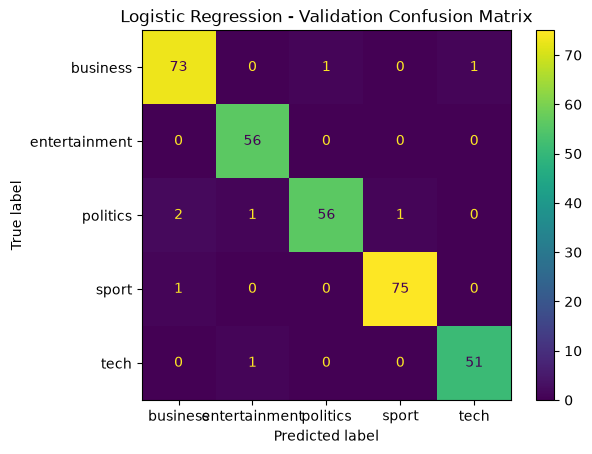

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred, labels=logistic_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=logistic_model.classes_
)

disp.plot()
plt.title("Logistic Regression - Validation Confusion Matrix")
plt.show()

In [20]:
from sklearn.metrics import classification_report

y_val_pred = logistic_model.predict(X_val_tfidf)

print(classification_report(y_val, y_val_pred))

               precision    recall  f1-score   support

     business       0.96      0.97      0.97        75
entertainment       0.97      1.00      0.98        56
     politics       0.98      0.93      0.96        60
        sport       0.99      0.99      0.99        76
         tech       0.98      0.98      0.98        52

     accuracy                           0.97       319
    macro avg       0.98      0.97      0.97       319
 weighted avg       0.98      0.97      0.97       319



In [19]:
train_accuracy = logistic_model.score(X_train_tfidf, y_train)
val_accuracy = logistic_model.score(X_val_tfidf, y_val)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Gap: {train_accuracy - val_accuracy:.4f}")

Training Accuracy: 0.9966
Validation Accuracy: 0.9749
Gap: 0.0217


In [18]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (1488, 14125)
Validation TF-IDF shape: (319, 14125)
Test TF-IDF shape: (320, 14125)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1488,) (1488,)
Validation: (319,) (319,)
Test: (320,) (320,)


In [15]:
X = df["text"]
y = df["category"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2127,)
y shape: (2127,)


In [14]:
empty_texts = (df["text"].str.strip() == "").sum()

print("Empty or blank articles:", empty_texts)

Empty or blank articles: 0


In [13]:
print(df["category"].value_counts())

print("\nPercentage:")
print(df["category"].value_counts(normalize=True) * 100)

category
sport            505
business         503
politics         403
entertainment    369
tech             347
Name: count, dtype: int64

Percentage:
category
sport            23.742360
business         23.648331
politics         18.946874
entertainment    17.348378
tech             16.314057
Name: proportion, dtype: float64


In [12]:
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)
print("Remaining duplicate texts:", df.duplicated(subset=["text"]).sum())

Shape after removing duplicates: (2127, 2)
Remaining duplicate texts: 0


In [11]:
duplicate_text_count = df.duplicated(subset=["text"]).sum()

conflicting_labels = (
    df.groupby("text")["category"]
      .nunique()
)

conflicting_count = (conflicting_labels > 1).sum()

print("Duplicate texts:", duplicate_text_count)
print("Duplicate texts with different categories:", conflicting_count)

Duplicate texts: 98
Duplicate texts with different categories: 0


In [10]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 98


In [9]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (2225, 2)

Columns: ['text', 'category']

Missing values:
text        0
category    0
dtype: int64


In [8]:
import pandas as pd

articles = []

for category in bbc_path.iterdir():
    if category.is_dir():
        for file_path in category.glob("*.txt"):
            with open(file_path, "r", encoding="utf-8") as file:
                text = file.read()

            articles.append({
                "text": text,
                "category": category.name
            })

df = pd.DataFrame(articles)

df.head()

,text,category
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


In [7]:
with open(sample_file, "r", encoding="utf-8") as file:
    sample_text = file.read()

print(sample_text[:500])

Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.

Time W


In [6]:
sample_file = next((bbc_path / "business").glob("*.txt"))

with open(sample_file, "r", encoding="latin-1") as file:
    sample_text = file.read()

print(sample_text[:1000])

Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (Â£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.

Time Warner said on Friday that it now owns 8% of search-engine Google. But its own internet business, AOL, had has mixed fortunes. It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters. However, the company said AOL's underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues. It hopes to increase subscribers by offering the online service free to TimeWarner internet customers and will try to sign up AO

In [5]:
category_counts = {}

for category in bbc_path.iterdir():
    if category.is_dir():
        category_counts[category.name] = len(list(category.glob("*.txt")))

total_articles = sum(category_counts.values())

for category, count in category_counts.items():
    percentage = (count / total_articles) * 100
    print(f"{category}: {count} ({percentage:.2f}%)")

business: 510 (22.92%)
entertainment: 386 (17.35%)
politics: 417 (18.74%)
sport: 511 (22.97%)
tech: 401 (18.02%)


In [4]:
for category in bbc_path.iterdir():
    if category.is_dir():
        file_count = len(list(category.glob("*.txt")))
        print(category.name, ":", file_count)

business : 510
entertainment : 386
politics : 417
sport : 511
tech : 401


In [3]:
bbc_path = data_path / "bbc"

[item.name for item in bbc_path.iterdir() if item.is_dir()]

['business', 'entertainment', 'politics', 'sport', 'tech']

In [2]:
from pathlib import Path

data_path = Path("../data")
list(data_path.iterdir())

[WindowsPath('../data/bbc')]

In [1]:
from pathlib import Path

data_path = Path("../data")
list(data_path.iterdir())

[WindowsPath('../data/bbc.classes'),
 WindowsPath('../data/bbc.docs'),
 WindowsPath('../data/bbc.mtx'),
 WindowsPath('../data/bbc.terms')]